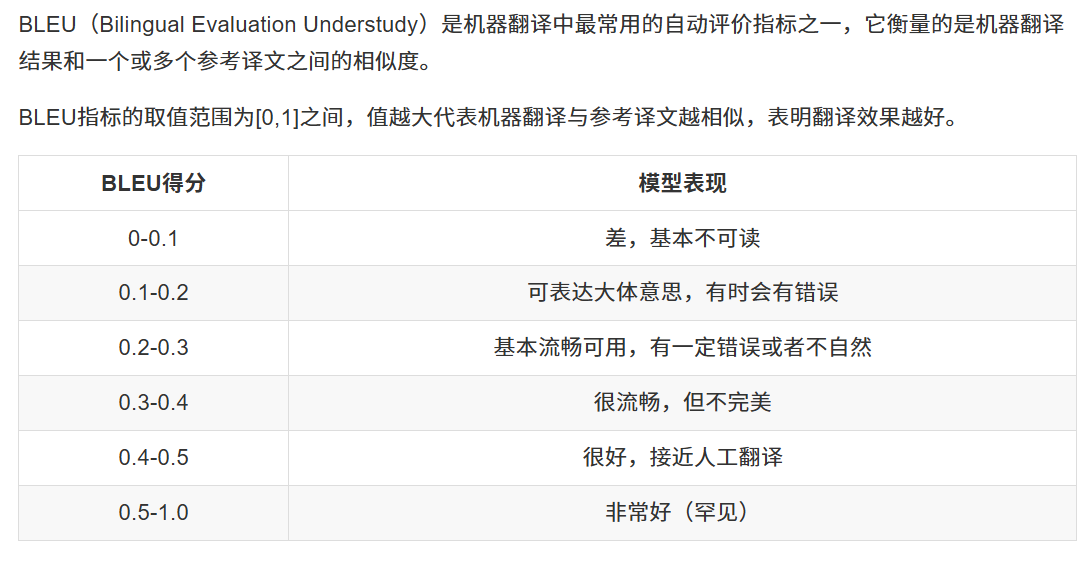
- 0.3以上就表示该翻译模型基本可用。

## 14.2.3 BLEU 详解

如果你不想了解 BLEU 的细节，本章节看到这里就可以停止。你只需要知道：

- **BLEU** 是衡量模型翻译好坏的指标  
- 取值范围 **[0, 1]**，**越大越好**
- 一般来说 **BLEU > 0.3** 表示该翻译模型基本可用

下面详细说明 BLEU 的计算过程。

---

### 14.2.3.1 一元准确率 $p_1$

$p_1$ 衡量的是模型翻译中**单个 token** 相对于参考翻译的准确率。

假设参考翻译 $T_r$ 为「今天天气很好」，模型翻译 $T_m$ 为「今天今天今天」。按**单个字**为一个 token 拆解。

如果只看“不同 token 是否出现过”，会误以为“今”“天”都在参考里，所以 $p_1=1$。但这显然不合理，因为模型大量重复了 token。

BLEU 使用 **clip（截断计数）** 来避免重复带来的虚高：

| token | $\text{count}(T_m, token)$ | $\min(\text{count}(T_m, token),\ \text{count}(T_r, token))$ |
|---|---:|---:|
| 今 | 3 | 1 |
| 天 | 3 | 2 |

- 第二列：token 在 $T_m$ 中出现次数，记为 $\text{count}$
- 第三列：在 $T_m$ 与 $T_r$ 的 count 中取较小者，记为 $\text{clip\_count}$

因此：

$$
p_1=\frac{\sum \text{clip\_count}}{\sum \text{count}}
=\frac{1+2}{3+3}
=\frac{3}{6}=0.5
$$

---

### 14.2.3.2 二元准确率 $p_2$

$p_2$ 衡量的是模型翻译中**连续 2 个 token（2-gram）**相对于参考翻译的准确率。

假设参考翻译 $T_r$ 为「今天天气不错」，模型翻译 $T_m$ 为「今天今天不错」。

则 $T_m$ 的 2-gram（按滑动窗口）包括：  
「今天」「天今」「今天」「天不」「不错」  
其中不同的 2-gram 为：「今天」「天今」「天不」「不错」

| 2-gram token | $\text{count}(T_m, token)$ | $\min(\text{count}(T_m, token),\ \text{count}(T_r, token))$ |
|---|---:|---:|
| 今天 | 2 | 1 |
| 天今 | 1 | 0 |
| 天不 | 1 | 0 |
| 不错 | 1 | 1 |

因此（注意此处是 **$p_2$**）：

$$
p_2=\frac{\sum \text{clip\_count}}{\sum \text{count}}
=\frac{1+0+0+1}{2+1+1+1}
=\frac{2}{5}=0.4
$$

同理可求 $p_3, p_4$（分别对应 3-gram 与 4-gram 的准确率）。

---

### 14.2.3.3 对 $p$ 值求平均：算术平均 vs 几何平均

当我们得到 $p_1,p_2,p_3,p_4$ 后，需要综合考虑不同 n-gram 长度的翻译精度。

- **算术平均**不够敏感：某些高值会掩盖低值（尤其是 0）
- BLEU 使用**几何平均**，对小值更敏感

假设各项权重相同（都是 $1/4$），几何平均为：

$$
\left(\prod_{n=1}^{4} p_n\right)^{\frac{1}{4}}
$$

例子：

$$
p_1=0.9,\quad p_2=0.7,\quad p_3=0.4,\quad p_4=0.0
$$

算术平均：

$$
\frac{0.9+0.7+0.4+0.0}{4}=0.5
$$

几何平均：

$$
\left(0.9\cdot 0.7\cdot 0.4\cdot 0.0\right)^{\frac14}=0
$$

另外，直接连乘可能造成数值下溢（很多小数相乘变成 0），因此通常使用**等价的对数形式**（这是公式“转变”的关键）：

$$
\left(\prod_{n=1}^{4} p_n\right)^{\frac{1}{4}}
=\exp\left(\sum_{n=1}^{4}\frac{1}{4}\log p_n\right)
$$

---

### 14.2.3.4 短句惩罚（Brevity Penalty, BP）

如果模型输出过短句子，n-gram 准确率可能很高，但翻译并不好，因此需要**短句惩罚**。

设：

- $r$：参考翻译长度（reference length）
- $m$：模型翻译长度（model length）

短句惩罚定义为：

$$

BP=\begin{cases}
1, & m>r \\
\exp\left(1-\frac{r}{m}\right), & m\le r
\end{cases}
$$

---

### 14.2.3.5 最终 BLEU 公式

默认各阶权重均为 $1/4$ 时：

$$
BLEU
= BP \cdot \exp\left(\sum_{n=1}^{4}\frac{1}{4}\log p_n\right)
$$

更一般地，允许每个 $p_n$ 具有不同权重 $w_n$（通常满足 $\sum_{n=1}^{4}w_n=1$）：

$$
BLEU
= BP \cdot \exp\left(\sum_{n=1}^{4}w_n\log p_n\right)
$$

（等价写法：$BLEU = BP \cdot \prod_{n=1}^{4}p_n^{w_n}$，但实现时常用上面的 log/exp 形式更稳定。）

### 代码实现

In [1]:
import sacrebleu

# 单个参考译文列表
references = [
    "今天天气很好。",
    "我喜欢在雨天散步。",
    "今天要早点下班。"
]

# 模型生成的候选翻译
hypotheses = [
    "今日天气不错。",
    "下雨的时候我喜欢散步。",
    "今天下班要早些。"
]

##### sacrebleu 需要 references 是 list[list[str]], 即使只有一个参考，也要是内层 list


In [2]:
references = [references]  # 变成：[[ref1, ref2, ref3]]

In [3]:
# 计算bleu
bleu = sacrebleu.corpus_bleu(hypotheses=hypotheses, references=references,tokenize='zh')

print(bleu)

BLEU = 16.31 69.2/34.8/10.0/2.9 (BP = 1.000 ratio = 1.083 hyp_len = 26 ref_len = 24)
